In [1]:
import os
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats
from scipy import optimize
from scipy.optimize import minimize, brentq
from scipy.stats import multivariate_normal, gaussian_kde

from numpy.linalg import det, inv, LinAlgError, svd, cholesky


Problem 1 is below

In [3]:
def mvgkl(m1, S1, m2, S2):
    """
    KL divergence between two multivariate Gaussians:
    N(m1,S1) || N(m2,S2)
    """
    m1 = m1.reshape(-1, 1)
    m2 = m2.reshape(-1, 1)

    d = m1.shape[0]

    S1_inv = np.linalg.inv(S1)
    S2_inv = np.linalg.inv(S2)

    term1 = np.trace(S2_inv @ S1)
    term2 = (m2 - m1).T @ S2_inv @ (m2 - m1)
    term3 = np.log(np.linalg.det(S2) / np.linalg.det(S1))

    kl = 0.5 * (term1 + term2 - d + term3)
    return float(kl)


In [5]:
np.random.seed(0)

mu1 = np.array([2, 3])
sigma1 = np.array([[1, 1.5],
                    [1.5, 3]])

mu2 = np.array([1, 3])
sigma2 = np.array([[1, 0.5],
                    [0.5, 3]])

G1 = np.random.multivariate_normal(mu1, sigma1, 1000)
G2 = np.random.multivariate_normal(mu2, sigma2, 1000)

mean1 = np.mean(G1, axis=0)
S1 = np.cov(G1.T)

mean2 = np.mean(G2, axis=0)
S2 = np.cov(G2.T)


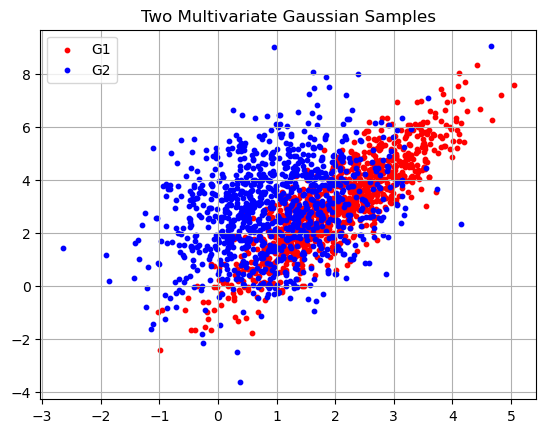

In [7]:
plt.figure()
plt.scatter(G1[:,0], G1[:,1], c='r', s=10, label='G1')
plt.scatter(G2[:,0], G2[:,1], c='b', s=10, label='G2')
plt.legend()
plt.title("Two Multivariate Gaussian Samples")
plt.grid()
plt.show()


This represents the two multivariate distributions, below I will calculate the KL distances between the data sets. 

In [9]:
n = 1000
KL_vals = np.zeros(n)

for i in range(n):
    X1 = np.random.multivariate_normal(mu1, sigma1, 1000)
    X2 = np.random.multivariate_normal(mu2, sigma2, 1000)

    m1 = np.mean(X1, axis=0)
    S1 = np.cov(X1.T)

    m2 = np.mean(X2, axis=0)
    S2 = np.cov(X2.T)

    KL_vals[i] = mvgkl(m1, S1, m2, S2)


/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_89289/3930328122.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(kl)


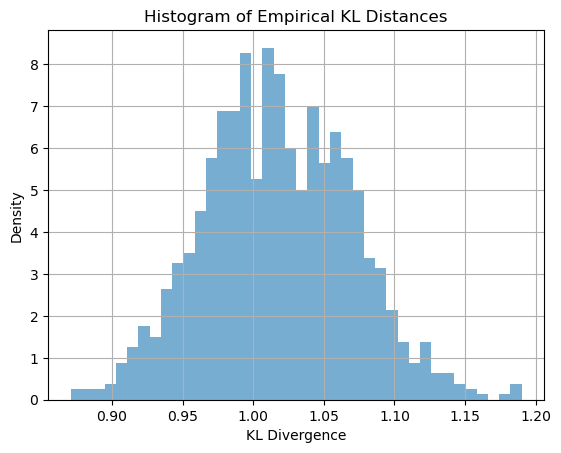

In [11]:
plt.figure()
plt.hist(KL_vals, bins=40, density=True, alpha=0.6)
plt.xlabel("KL Divergence")
plt.ylabel("Density")
plt.title("Histogram of Empirical KL Distances")
plt.grid()
plt.show()


In [13]:
# Utility: complexity_C (from your MATLAB)
# ---------------------------
def complexity_C(ACOV):
    # C(Sigma) = (r/2)*log(trace(Sigma)/r) - 0.5*log(det(Sigma))
    if ACOV is None:
        return np.inf
    S = np.array(ACOV, dtype=float)
    if S.size == 0 or np.any(np.isnan(S)) or np.any(np.isinf(S)) or not np.isrealobj(S):
        return np.inf
    S = 0.5 * (S + S.T)
    s = np.linalg.svd(S, compute_uv=False)
    if s.size == 0:
        return np.inf
    tol = max(S.shape) * np.finfo(float).eps * max(s)
    r = np.sum(s > tol)
    trS = np.sum(s)
    if r == 0 or trS <= 0:
        return np.inf
    try:
        R = cholesky(S)
        logdetS = 2.0 * np.sum(np.log(np.diag(R)))
    except LinAlgError:
        if np.any(s <= 0):
            return np.inf
        logdetS = np.sum(np.log(s))
    C = (r / 2.0) * np.log(trS / r) - 0.5 * logdetS
    return float(C)


In [15]:

# ---------------------------
# Numeric Hessian approximation (central differences)
# Returns Hessian matrix of func at params
# ---------------------------
def numeric_hessian(func, params, eps=1e-5):
    p0 = np.asarray(params, dtype=float)
    n = p0.size
    H = np.zeros((n, n), dtype=float)
    f0 = float(func(p0))
    # central differences
    for i in range(n):
        ei = np.zeros(n); ei[i] = eps
        f1 = float(func(p0 + ei))
        f2 = float(func(p0 - ei))
        H[i, i] = (f1 - 2.0 * f0 + f2) / (eps * eps)
        for j in range(i + 1, n):
            ej = np.zeros(n); ej[j] = eps
            f_pp = float(func(p0 + ei + ej))
            f_pm = float(func(p0 + ei - ej))
            f_mp = float(func(p0 - ei + ej))
            f_mm = float(func(p0 - ei - ej))
            H_ij = (f_pp - f_pm - f_mp + f_mm) / (4.0 * eps * eps)
            H[i, j] = H_ij
            H[j, i] = H_ij
    return H

In [17]:
# ---------------------------
# Helpers: map distribution names to scipy.stats objects & wrapper for fit/logpdf/ppf
# We will support a similar set as MATLAB: normal, expon, gamma, weibull (weibull_min),
# lognormal (lognorm), t (scipy's t), invgauss, logistic, rayleigh, genextreme (GEV)
# ---------------------------
DIST_REGISTRY = {
    'normal': {
        'dist': stats.norm,
        'k': 2
    },
    'exponential': {
        'dist': stats.expon,
        'k': 1
    },
    'gamma': {
        'dist': stats.gamma,
        'k': 2
    },
    'weibull': {
        'dist': stats.weibull_min,
        'k': 2
    },
    'lognormal': {
        'dist': stats.lognorm,
        'k': 2
    },
    'tlocationscale': {
        'dist': stats.t,
        'k': 3
    },
    'inversegaussian': {
        'dist': stats.invgauss,
        'k': 2
    },
    'logistic': {
        'dist': stats.logistic,
        'k': 2
    },
    'rayleigh': {
        'dist': stats.rayleigh,
        'k': 1
    },
    'gev': {
        'dist': stats.genextreme,
        'k': 3
    }
}

In [19]:
# ---------------------------
# Compute -loglik for a given scipy frozen distribution and params vector (for numeric Hessian)
# We will create an objective function that takes a parameter vector (length depends on dist)
# and returns negative log-likelihood on the given data
# ---------------------------
def make_negloglik(data, dist_name):
    dist = DIST_REGISTRY[dist_name]['dist']

    # We need to decide parameter ordering. scipy's .fit returns parameters in the order:
    # For most distributions: shape(s) (if any), loc, scale. .logpdf takes (x, *shapes, loc=..., scale=...)
    def negloglik_from_vector(theta):
        # theta is a 1-d numpy vector of length m
        # We must map it into args for logpdf: shapes... and loc, scale (if present)
        # We'll make a convention: last two entries are loc and scale if dist has loc and scale
        th = np.asarray(theta).ravel()
        # Determine number of shape parameters via calling dist.numargs (scipy provides)
        num_shapes = getattr(dist, 'numargs', 0)
        # Allow 0..num_shapes shapes; some dists (norm) have numargs==0
        if num_shapes == 0:
            if th.size == 2:
                loc = th[-2]; scale = th[-1]
                shapes = []
            elif th.size == 1:
                # maybe only scale or loc? treat as scale with loc=0
                loc = 0.0; scale = float(th[0])
                shapes = []
            else:
                loc = float(th[-2]) if th.size >= 2 else 0.0
                scale = float(th[-1]) if th.size >= 1 else 1.0
                shapes = []
        else:
            # shapes followed by loc, scale
            if th.size < num_shapes + 2:
                raise ValueError("Parameter vector length mismatch for dist %s" % dist_name)
            shapes = list(th[:num_shapes])
            loc = float(th[num_shapes])
            scale = float(th[num_shapes + 1])
        # compute negative loglik; use logpdf with keyword args
        try:
            # build args for logpdf
            if len(shapes) == 0:
                lp = dist.logpdf(data, loc=loc, scale=scale)
            else:
                lp = dist.logpdf(data, *shapes, loc=loc, scale=scale)
            # sum negative log-likelihood
            nll = -np.sum(lp)
            if not np.isfinite(nll):
                return 1e300
            return float(nll)
        except Exception:
            return 1e300

    return negloglik_from_vector

In [21]:
# ---------------------------
# Compute R^2 for QQ (regression fit between empirical sorted and theoretical quantiles)
# ---------------------------
def qq_r2(y_sorted, x_theor):
    # interpolate if length differs
    if x_theor.size != y_sorted.size:
        x_theor = np.interp(np.linspace(0, 1, y_sorted.size), np.linspace(0, 1, x_theor.size), x_theor)
    coeffs = np.polyfit(x_theor, y_sorted, 1)
    yhat = np.polyval(coeffs, x_theor)
    ss_res = np.sum((y_sorted - yhat) ** 2)
    ss_tot = np.sum((y_sorted - np.mean(y_sorted)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(r2)
    

In [23]:
# ---------------------------
# Main pipeline: choose which univariate data to analyze
# ---------------------------
def main():
    outdir = "./out"
    os.makedirs(outdir, exist_ok=True)
    ts = time.strftime("%Y-%m-%d_%H-%M-%S")

   
    data = KL_vals.astype(float)    # <--- change this line to choose different univariate data

    # positivity adjustment used in MATLAB for positive-support dists:
    data_pos = np.copy(data)
    data_pos[data_pos <= 0] = np.finfo(float).eps

    n = data.size
    q = (np.arange(1, n + 1) / (n + 1.0))

    dist_names = list(DIST_REGISTRY.keys())
    D = len(dist_names)

    # preallocate results
    Names = []
    K = []
    logL = []
    AIC = []
    BIC = []
    ICOMP = []
    R2 = []
    Params = []

    # loop distributions
    for name in dist_names:
        dist = DIST_REGISTRY[name]['dist']
        k = DIST_REGISTRY[name]['k']
        Names.append(name)
        K.append(k)

        # check support: quick heuristic
        try:
            support_ok = True
            if name in ('exponential', 'gamma', 'weibull', 'lognormal', 'inversegaussian', 'rayleigh'):
                if np.any(data <= 0):
                    support_ok = False
            # else allow full real
            if not support_ok:
                print(f"Skipping {name} (data violate support)")
                logL.append(np.nan); AIC.append(np.nan); BIC.append(np.nan); ICOMP.append(np.nan); R2.append(np.nan); Params.append(None)
                continue
        except Exception:
            pass

        print(f"Fitting {name:12s} ... ", end="", flush=True)

        # choose which data to pass to fit (for positive-support dists pass data_pos)
        data_for_fit = data_pos if name in ('exponential', 'gamma', 'weibull', 'lognormal', 'inversegaussian', 'rayleigh') else data

        # SCIPY's fit API returns shape parameters (if any), loc, scale
        try:
            phat = dist.fit(data_for_fit)
            # build frozen dist for pdf/ppf
            # phat is tuple like (shapes..., loc, scale) or (loc, scale) if no shapes
            # use those directly to compute logpdf
            # compute negative log-likelihood
            try:
                # log-likelihood
                lp = dist.logpdf(data_for_fit, *phat[:-2], loc=phat[-2], scale=phat[-1]) if dist.numargs > 0 else dist.logpdf(data_for_fit, loc=phat[-2], scale=phat[-1])
            except Exception:
                # some distributions accept args differently (e.g., invgauss)
                try:
                    lp = dist.logpdf(data_for_fit, *phat)
                except Exception:
                    lp = np.array([ -np.inf if np.isnan(x) else x for x in dist.logpdf(data_for_fit, *phat) ])
            total_logL = np.sum(lp)
            nlogL = -total_logL
            logL.append(-nlogL)

            Params.append(phat)

            # ACOV: attempt numeric Hessian of negative log-likelihood at phat
            try:
                negloglik = make_negloglik(data_for_fit, name)
                # need a parameter vector in the same order as phat
                theta0 = np.array(phat, dtype=float)
                H = numeric_hessian(negloglik, theta0, eps=1e-4)
                # observed information matrix ~ H (since H is Hessian of negloglik); ACOV = inv(H)
                # guard singular / non-posdef
                if np.any(np.isnan(H)) or not np.all(np.isfinite(H)):
                    ACOV = None
                else:
                    ACOV = None
                    try:
                        ACOV = inv(H)
                    except Exception:
                        ACOV = None
            except Exception as e:
                ACOV = None

            # compute criteria
            AIC_val = 2.0 * len(theta0) + 2.0 * nlogL
            BIC_val = len(theta0) * np.log(n) + 2.0 * nlogL
            AIC.append(AIC_val)
            BIC.append(BIC_val)

            # ICOMP uses complexity_C(ACOV)
            comp = complexity_C(ACOV)
            ICOMP_val = 2.0 * nlogL + 2.0 * comp
            ICOMP.append(ICOMP_val)

            # QQ: theoretical quantiles using ppf
            try:
                # build theoretical quantiles x_theor by evaluating ppf at q
                if dist.numargs > 0:
                    shapes = phat[:dist.numargs]
                    loc = phat[-2]; scale = phat[-1]
                    x_theor = dist.ppf(q, *shapes, loc=loc, scale=scale)
                else:
                    loc = phat[-2]; scale = phat[-1]
                    x_theor = dist.ppf(q, loc=loc, scale=scale)
                x_emp = np.sort(data_for_fit)
                r2 = qq_r2(x_emp, x_theor)
            except Exception:
                r2 = np.nan
            R2.append(r2)

            # plot QQ and save
            try:
                fig, ax = plt.subplots(figsize=(6, 5))
                ax.plot(x_theor, x_emp, 'o', markersize=4, label='Empirical vs Theoretical')
                # fitted line
                pfit = np.polyfit(x_theor, x_emp, 1)
                xx = np.linspace(np.nanmin(x_theor), np.nanmax(x_theor), 200)
                yy = np.polyval(pfit, xx)
                ax.plot(xx, yy, '-', linewidth=1.4, label=f'Fit: y={pfit[0]:.3f}x{pfit[1]:+.3f}')
                ax.plot(xx, xx, '--k', label='45°')
                ax.grid(True)
                ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Empirical Quantiles')
                ax.set_title(f'Q-Q: {name} (R^2={r2:.4f})')
                ax.legend(loc='best')
                fname = os.path.join(outdir, f"QQ_{name}_{ts}.png")
                fig.tight_layout()
                fig.savefig(fname, dpi=220)
                plt.close(fig)
            except Exception:
                pass

            print(f"done. (-2logL={-2*total_logL:.3f} | AIC={AIC_val:.3f} | BIC={BIC_val:.3f} | ICOMP={ICOMP_val:.3f} | R2={r2:.4f})")
        except Exception as e:
            print(f"FAILED: {str(e)}")
            logL.append(np.nan); AIC.append(np.nan); BIC.append(np.nan); ICOMP.append(np.nan); R2.append(np.nan); Params.append(None)

    # assemble results DataFrame
    df = pd.DataFrame({
        'Distribution': Names,
        'NumParams': K,
        'Neg2LogL': [-2.0 * float(x) if np.isfinite(x) else np.nan for x in logL],
        'AIC': AIC,
        'BIC': BIC,
        'ICOMP': ICOMP,
        'R2': R2
    })
    print("\n=== Criteria Table ===")
    print(df)

    csv_file = os.path.join(outdir, f"Distribution_Criteria_{ts}.csv")
    df.to_csv(csv_file, index=False)
    print("Wrote CSV:", csv_file)

    tex_file = os.path.join(outdir, f"Distribution_Criteria_{ts}.tex")
    with open(tex_file, 'w') as f:
        f.write(df.to_latex(index=False))
    print("Wrote LaTeX:", tex_file)

    # winners
    try:
        ia = int(df['AIC'].idxmin())
        ib = int(df['BIC'].idxmin())
        ic = int(df['ICOMP'].replace([np.inf, -np.inf], np.nan).idxmin())
        print("\nWinners (name -> values):")
        print(" AIC  ->", df.loc[ia, ['Distribution', 'AIC', 'BIC', 'ICOMP', 'Neg2LogL', 'R2']].to_dict())
        print(" BIC  ->", df.loc[ib, ['Distribution', 'AIC', 'BIC', 'ICOMP', 'Neg2LogL', 'R2']].to_dict())
        print(" ICOMP->", df.loc[ic, ['Distribution', 'AIC', 'BIC', 'ICOMP', 'Neg2LogL', 'R2']].to_dict())
    except Exception:
        print("Could not determine winners (some criteria may be NaN/Inf).")

    return df


if __name__ == "__main__":
    df = main()


Fitting normal       ... done. (-2logL=-3067.945 | AIC=-3063.945 | BIC=-3054.129 | ICOMP=-3067.827 | R2=0.9975)
Fitting exponential  ... done. (-2logL=-1844.116 | AIC=-1840.116 | BIC=-1830.301 | ICOMP=-1134.920 | R2=0.8460)
Fitting gamma        ... done. (-2logL=-3071.793 | AIC=-3065.793 | BIC=-3051.069 | ICOMP=-3035.553 | R2=0.9986)
Fitting weibull      ... done. (-2logL=-3070.072 | AIC=-3064.072 | BIC=-3049.349 | ICOMP=-3056.405 | R2=0.9978)
Fitting lognormal    ... done. (-2logL=-3071.700 | AIC=-3065.700 | BIC=-3050.977 | ICOMP=-3049.263 | R2=0.9986)
Fitting tlocationscale ... done. (-2logL=-3067.926 | AIC=-3061.926 | BIC=-3047.203 | ICOMP=-3042.879 | R2=0.9975)
Fitting inversegaussian ... done. (-2logL=-3059.453 | AIC=-3053.453 | BIC=-3038.730 | ICOMP=-3031.878 | R2=0.9942)
Fitting logistic     ... done. (-2logL=-3041.017 | AIC=-3037.017 | BIC=-3027.201 | ICOMP=-3040.493 | R2=0.9898)
Fitting rayleigh     ... done. (-2logL=-2823.931 | AIC=-2819.931 | BIC=-2810.115 | ICOMP=-2821.399 

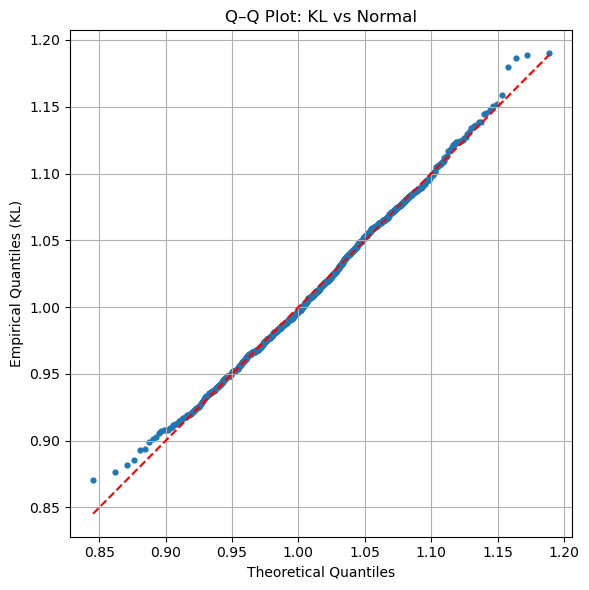

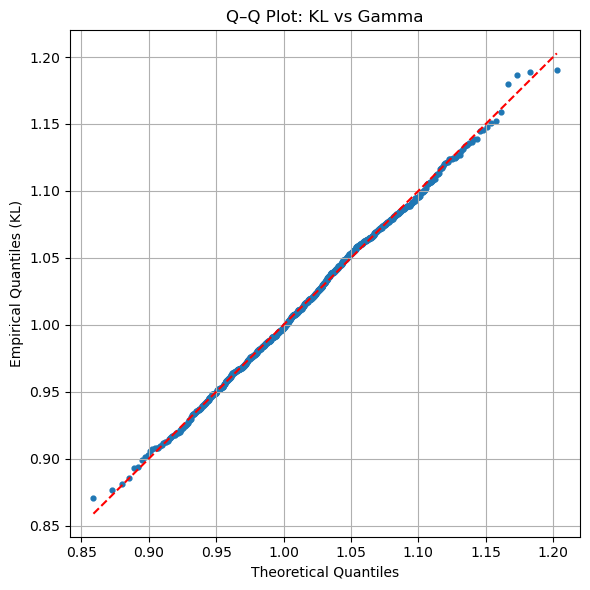

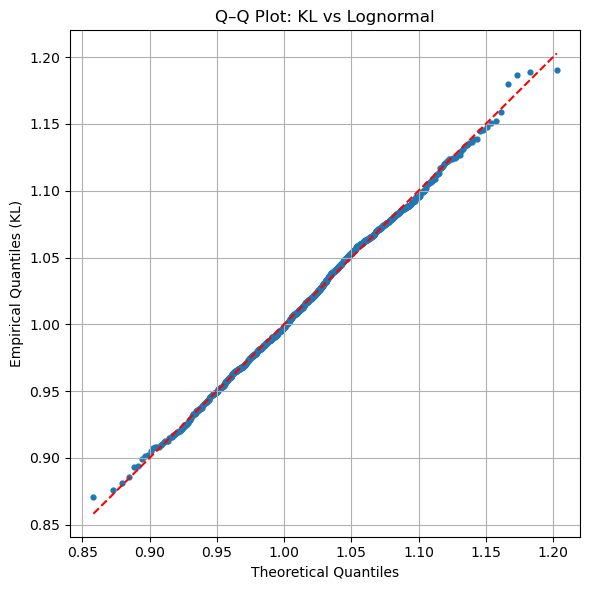

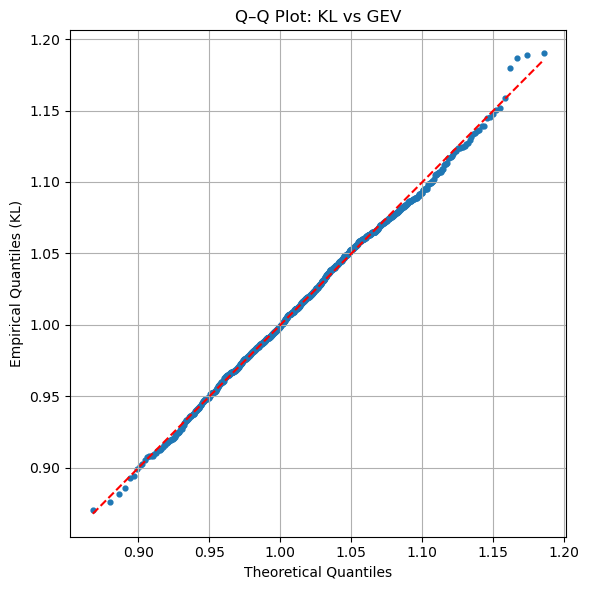

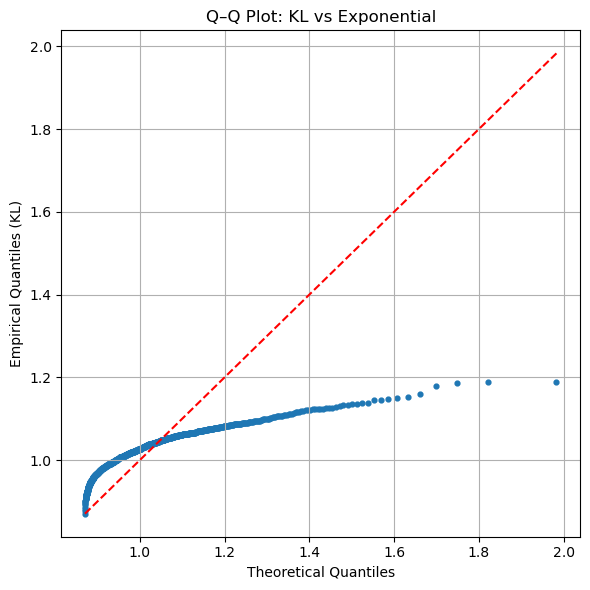

In [25]:
data = KL_vals.astype(float)

# -------------------------------
np.random.seed(0)
KL = data  

KL = KL[KL > 0]  # enforce positivity
n = len(KL)

# -------------------------------
# DISTRIBUTIONS TO TEST
# -------------------------------
distributions = {
    "Normal": stats.norm,
    "Gamma": stats.gamma,
    "Lognormal": stats.lognorm,
    "GEV": stats.genextreme,
    "Exponential": stats.expon
}

# -------------------------------
# STORAGE
# -------------------------------
results = []

# -------------------------------
# QQ PLOT + FIT LOOP
# -------------------------------
for name, dist in distributions.items():

    # ---- MLE Fit ----
    params = dist.fit(KL)

    # ---- Log-Likelihood ----
    logL = np.sum(dist.logpdf(KL, *params))

    # ---- AIC / BIC/ ICOMP ----
    k = len(params)
    AIC = 2 * k - 2 * logL
    BIC = k * np.log(n) - 2 * logL

    results.append([name, k, -2*logL, AIC, BIC])

    # ---- QQ PLOT ----
    sorted_KL = np.sort(KL)
    p = (np.arange(1, n+1) - 0.5) / n
    theoretical_q = dist.ppf(p, *params)

    plt.figure(figsize=(6,6))
    plt.scatter(theoretical_q, sorted_KL, s=12)
    plt.plot(theoretical_q, theoretical_q, 'r--')
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Empirical Quantiles (KL)")
    plt.title(f"Q–Q Plot: KL vs {name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()




The normal distribution performs the best on ICOMP and BIC whereas the Gamma distribution performs the best on AIC. 

Problem 2 is below. 

In [27]:
# ---------------- DCT ----------------
def dct1d(data):
    data = np.asarray(data, dtype=float)
    n = data.shape[0]

    reordered = np.concatenate([data[::2], data[-2::-2]])

    weights = np.ones(n, dtype=complex)
    weights[1:] = 2 * np.exp(-1j * np.pi * np.arange(1, n) / (2 * n))

    return np.real(weights * np.fft.fft(reordered))

# ---------------- IDCT ----------------
def idct1d(data):
    data = np.asarray(data, dtype=complex)
    n = data.shape[0]

    weights = n * np.exp(1j * np.pi * np.arange(n) / (2 * n))
    tmp = np.real(np.fft.ifft(weights * data))

    out = np.zeros(n)
    out[::2] = tmp[:(n + 1) // 2]
    out[1::2] = tmp[:n // 2 - 1:-1]

    return out

# ---------------- FIXED POINT ----------------
def fixed_point(t, N, I, a2):
    l = 7
    f = 2 * np.pi ** (2 * l) * np.sum(I ** l * a2 * np.exp(-I * np.pi ** 2 * t))
    for s in range(l - 1, 1, -1):
        K0 = np.prod(np.arange(1, 2 * s, 2)) / np.sqrt(2 * np.pi)
        const = (1 + (1 / 2) ** (s + 0.5)) / 3
        time = (2 * const * K0 / (N * f)) ** (2 / (3 + 2 * s))
        f = 2 * np.pi ** (2 * s) * np.sum(I ** s * a2 * np.exp(-I * np.pi ** 2 * time))

    return t - (2 * N * np.sqrt(np.pi) * f) ** (-2 / 5)

# ---------------- FINAL KDE ----------------
def kde_botev(data, n=4096, xmin=None, xmax=None):
    data = np.asarray(data).ravel()

    if xmin is None:
        xmin = data.min() - 0.1 * (data.max() - data.min())
    if xmax is None:
        xmax = data.max() + 0.1 * (data.max() - data.min())

    R = xmax - xmin
    xmesh = np.linspace(xmin, xmax, n)

    #CRITICAL FIX: FORCE HIST LENGTH = n
    hist, _ = np.histogram(data, bins=n, range=(xmin, xmax))
    hist = hist.astype(float)
    hist /= hist.sum()                # normalize
    hist = np.pad(hist, (0, 1), mode="constant")[:n]  # FORCE length n

    N = len(np.unique(data))

    # DCT
    a = dct1d(hist)                   # ength n

    I = np.arange(1, n) ** 2
    a2 = (a[1:] / 2) ** 2

    try:
        t_star = brentq(lambda t: fixed_point(t, N, I, a2), 1e-6, 0.1)
    except:
        t_star = 0.28 * N ** (-2 / 5)

    #SAFE SMOOTHING – LENGTH MATCHED
    a_t = a * np.exp(-np.arange(n) ** 2 * np.pi ** 2 * t_star / 2)

    density = idct1d(a_t) / R

    f = 2 * np.pi ** 2 * np.sum(I * a2 * np.exp(-I * np.pi ** 2 * t_star))
    t_cdf = (np.sqrt(np.pi) * f * N) ** (-2 / 3)

    a_cdf = a * np.exp(-np.arange(n) ** 2 * np.pi ** 2 * t_cdf / 2)
    cdf = np.cumsum(idct1d(a_cdf)) * (xmesh[1] - xmesh[0]) / R

    bandwidth = np.sqrt(t_star) * R

    return bandwidth, density, xmesh, cdf


/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_89289/3446191511.py:34: RuntimeWarning: invalid value encountered in scalar power
  time = (2 * const * K0 / (N * f)) ** (2 / (3 + 2 * s))


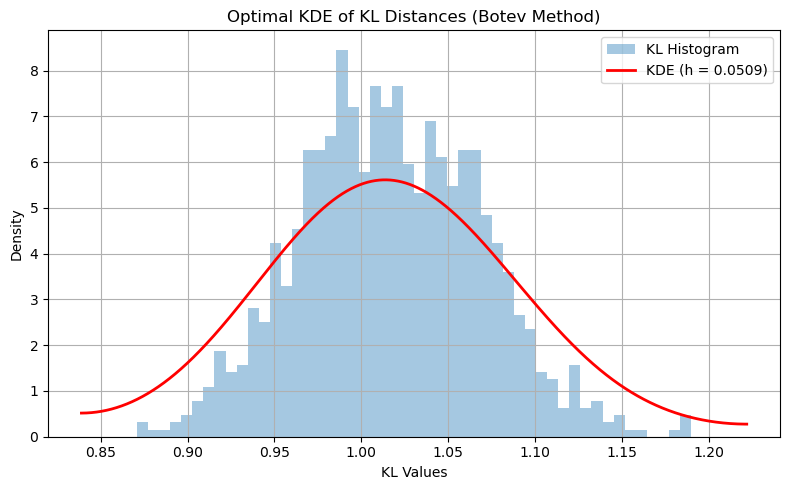

In [29]:
# ---- Compute KDE with Optimal Bandwidth ----
bandwidth, density, xmesh, cdf = kde_botev(KL, n=4096)

# ---- Plot KDE vs Histogram ----
plt.figure(figsize=(8, 5))
plt.hist(KL, bins=50, density=True, alpha=0.4, label="KL Histogram")
plt.plot(xmesh, density, 'r', lw=2, label=f"KDE (h = {bandwidth:.4f})")
plt.xlabel("KL Values")
plt.ylabel("Density")
plt.title("Optimal KDE of KL Distances (Botev Method)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


The Histogram looks fairly similar to the histogram in problem 1. It is the same data as the KL values from problem 1.  

Problem 4 is below

In [31]:
xbar = np.mean(data)
s = np.std(data, ddof=1)
z = (data - xbar) / s

In [33]:
x_edges = np.array([-np.inf, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5, np.inf])
k = 8


In [35]:
p = np.array([
    stats.norm.cdf(x_edges[i+1]) - stats.norm.cdf(x_edges[i])
    for i in range(k)
])

# Expected frequencies
e = n * p


In [39]:
f, _ = np.histogram(z, bins=x_edges)


In [41]:
m = 2
AIC_8 = -2 * np.sum(f * np.log(p + 1e-12)) + 2 * (k - 1 - m)


In [43]:
Sigma = np.diag(p) - np.outer(p, p)
Sigma_inv = inv(Sigma)

s = np.linalg.matrix_rank(Sigma)
C1 = (s/2)*np.log(np.trace(Sigma_inv)/s) - (1/2)*np.log(det(Sigma_inv))

ICOMP_8 = -2*np.sum(f*np.log(p+1e-12)) + 2*C1


/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_89289/2694310834.py:5: RuntimeWarning: divide by zero encountered in log
  C1 = (s/2)*np.log(np.trace(Sigma_inv)/s) - (1/2)*np.log(det(Sigma_inv))


In [45]:
p6 = np.array([
    p[0] + p[1],
    p[2],
    p[3],
    p[4],
    p[5],
    p[6] + p[7]
])

f6 = np.array([
    f[0] + f[1],
    f[2],
    f[3],
    f[4],
    f[5],
    f[6] + f[7]
])

k6 = 6


In [47]:
AIC_6 = -2 * np.sum(f6 * np.log(p6 + 1e-12)) + 2 * (k6 - 1 - m)


In [49]:
Sigma6 = np.diag(p6) - np.outer(p6, p6)
Sigma6_inv = inv(Sigma6)

s6 = np.linalg.matrix_rank(Sigma6)
C1_6 = (s6/2)*np.log(np.trace(Sigma6_inv)/s6) - (1/2)*np.log(det(Sigma6_inv))

ICOMP_6 = -2*np.sum(f6*np.log(p6+1e-12)) + 2*C1_6


/var/folders/7v/_n9jb2r93vg6ygkfm_0sl5zc0000gn/T/ipykernel_89289/439366435.py:5: RuntimeWarning: invalid value encountered in log
  C1_6 = (s6/2)*np.log(np.trace(Sigma6_inv)/s6) - (1/2)*np.log(det(Sigma6_inv))


In [51]:
table = pd.DataFrame({
    "Model": ["Normal (k=8)", "Normal (k=6 pooled)"],
    "AIC": [AIC_8, AIC_6],
    "ICOMP": [ICOMP_8, ICOMP_6]
})

print(table)


                 Model          AIC  ICOMP
0         Normal (k=8)  4020.122794    inf
1  Normal (k=6 pooled)  3594.094804    NaN


In the case above, I would argue to pool the distributions as the AIC for the pooled at 6 bins is much smaller, however the earlier information criteria scoring was much lower without testing the distribution against a normal distribution. 

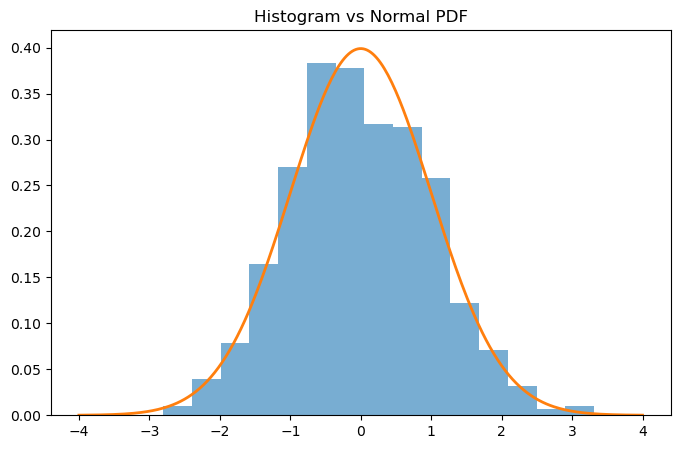

In [53]:
plt.figure(figsize=(8,5))
plt.hist(z, bins=15, density=True, alpha=0.6)
x = np.linspace(-4,4,300)
plt.plot(x, stats.norm.pdf(x), linewidth=2)
plt.title("Histogram vs Normal PDF")
plt.show()


The histogram suggests that the KL distances could be normally distributed with a slight right skew. 